# 07. 메타러너
- 이산형 처치의 경우, 이질적 효과 프레임워크에서 추정하고 싶은 CATE는

$$\tau(x) = E[Y_i(1) - Y_i (0) | X] = E[\tau_i | X]$$


- **또는 연속형 처치의 경우 $E[\delta Y_i(t) | X]$, 대상이 처치에 얼마나 민감한지가 중요**

    $\rightarrow$ 모든 대상에게 처치를 할 수 없고, 처치의 우선순위를 정해야 하는 경우 필요

    - 예) 할인을 제공하고 싶지만 예산이 한정된 경우나, 어떤 대상에게는 처치효과가 긍정적이지만 다른 대상에는 부정적인 경우

<br>

- **메타러너 (MetaLearner)는 기존 예측 머신러닝 알고리즘을 활용해서 처치효과를 추정하는 간단한 방법**
    - 메타러너를 ATE추정에 사용할 수 있지만, 일반적으로 고차원 데이터를 잘 처리하기 때문에 주로 CATE 추정에 사용
    - **메타러너는 예측 모델을 인과추론에 재활용하는 역할 (선형회귀, 의사결정 트리, 신경망, 가우스 과정 등)** 

    $\rightarrow$ **메타러너의 효과적인 활용은 사용하는 머신러닝 방법에 크게 좌우됨**

<br>

<hr>

## 07-01. 이산형 처치 메타러너
- 예) 온라인 소매업체의 마케팅
    - 목표는 어떤 고객이 마케팅 이메일을 잘 받는지 파악
    - 메일은 고객의 소비를 늘릴 잠재력이 있지만, 일부 고객은 마ㅔ팅 이메일 수신을 선호하지 않음

    $\rightarrow$ 이메일이 고객의 미래 구매량에 미치는 조건부 평균 처치효과를 추정

    $\rightarrow$ CATE추정값을 바탕으로 누구에게 메일을 발송하면 효율적일지에 관한 비즈니스 전략 수립 가능


In [1]:
# pip install fklearn
# pip install econml
# pip install casualml

In [2]:
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib

# from fklearn.causal.validation.curves import relative_cumulative_gain_curve
# from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve

from cycler import cycler

color=['0.0', '0.4', '0.8']
default_cycler = (cycler(color=color))
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)

In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 8)

<br>

- 이메일 발송 여부인 처치변수 `mkt_email`
- 한 달 후의 구매금액인 결과변수 `next_mnth_pv`

In [5]:
data_biased = pd.read_csv("./data/email_obs_data.csv")
data_rnd = pd.read_csv("./data/email_rnd_data.csv")

print(len(data_biased), len(data_rnd))
data_rnd.head()

300000 10000


,mkt_email,next_mnth_pv,age,tenure,...,jewel,books,music_books_movies,health
0,0,244.26,61.0,1.0,...,1,0,0,2
1,0,29.67,36.0,1.0,...,1,0,2,2
2,0,11.73,64.0,0.0,...,0,1,0,1
3,0,41.41,74.0,0.0,...,0,4,1,0
4,0,447.89,59.0,0.0,...,1,1,2,1



- CATE 모델 개발을 간소화하기 위해 처치, 결과, 공변량, 훈련 및 테스트 셋을 저장한 변수를 생성

In [6]:
y = "next_mnth_pv"
T = "mkt_email"
X = list(data_rnd.drop(columns=[y, T]).columns)

train, test = data_biased, data_rnd

<br>

### 01. T 러너

- T러너는 단순한 모델이므로, 처치가 이산형으로 주어진 상황일 때, 처음 시도하기 좋음
- 하지만 상황에 따라 정규화 편향 (Regularization Bias)가 발생하기 쉬움

<br>

- T러너는 잠재적 결과 $Y_i$를 추정하기 위해 모든 처치에 대해 하나의 결과 모델 $\mu)t (x)$를 적합

$$
\mu_0 (x) = E[Y|T = 0, X]
$$

$$
\mu_1 (x) = E[Y|T = 1, X]
$$

- 각 처치에 대한 반사실 예측을 하고 CATE를 추정

$$
\hat{\tau}(x)_i = \hat{\mu_i}(X_i) - \hat{\mu_0}(X_i)
$$

<br>

#### T러너의 다이어그램
1. T러너가 각자 T=1, T=0에서 머신러닝 모델을 학습
2. 예측 시점에 두 모델을 모두 사용하여 실험군과 대조군의 차이를 추정

<img src='img/t-learner.png' width=800>

<br>

- 결과 모델로 부스트 회귀 트리를 사용

In [9]:
from lightgbm import LGBMRegressor

In [41]:
np.random.seed(123)

m0 = LGBMRegressor(verbosity=-1)
m1 = LGBMRegressor(verbosity=-1)

m0.fit(train.query(f"{T}==0")[X], train.query(f"{T}==0")[y])
m1.fit(train.query(f"{T}==1")[X], train.query(f"{T}==1")[y]);

<br>

- 두 개의 모델을 통해서 CATE를 예측


In [42]:
t_learner_cate_test = test.assign(
    cate=m1.predict(test[X]) - m0.predict(test[X])
)

<br>

#### 모델의 평가 (상대 누적 이득 곡선)
- 처치효과가 가장 높은 고객부터 가장 낮은 고객까지 고객을 올바르게 정렬했는지에만 관심

In [43]:
from fklearn.causal.validation.curves import relative_cumulative_gain_curve
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve

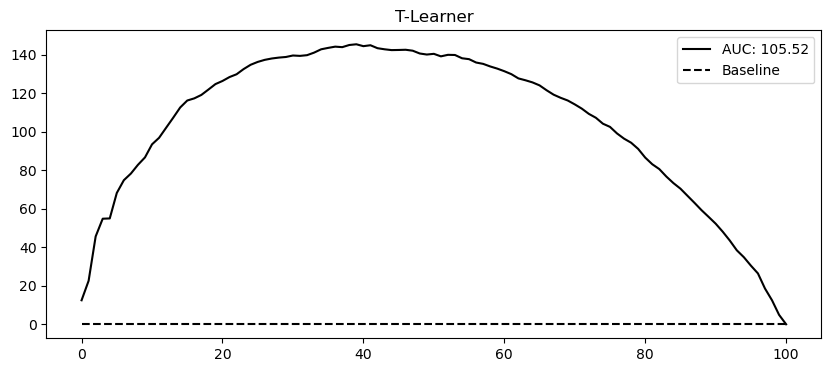

In [44]:
gain_curve_test = relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(t_learner_cate_test, T, y, prediction="cate")

plt.figure(figsize=(10,4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("T-Learner")
plt.show()


<br>

#### 대조군이 많고 실험군의 데이터가 매우 적을 때
- 처치에 큰 비용이 들어가는 사례에서 매우 흔한 상황
- **과적합을 피하기 위해 $\hat{\mu_1}$ 모델은 단순해질 가능성이 높음**

    **반대로, $\hat{\mu_0}$ 모델은 더 복잡해질 수 있지만, 데이터가 풍부하므로 과적합을 방지할 수 있음**
    
    (두 모델에 동일한 하이퍼파라미터를 사요하더라도 이러한 상황이 발생할 수 있음)

    $\rightarrow$ 데이터가 적으면 더 단순한 모델을 사용해야 함

- 아래의 두 모델 모두 각각의 표본 크기에 최적화되어 예측 성능이 좋지만, 
    
    **이 모델을 사용하여 $CATE\;\hat{\tau} = \mu_1(X) - \mu_0(X)$를 계산하면, $\mu_0(X)$의 비선형성과 $\mu_1(X)$의 선형성 차이 때문에 비선형 CATE(점선에서 실선을 뺀 값)가 됨**

    $\rightarrow$ **데이터의 불균형으로 인하여, 모델간 적합의 불균형 발생** 

    $\rightarrow$ **두 모델의 차이인 CATE의 왜곡 발생**

    $\rightarrow$ **X러너의 사용**

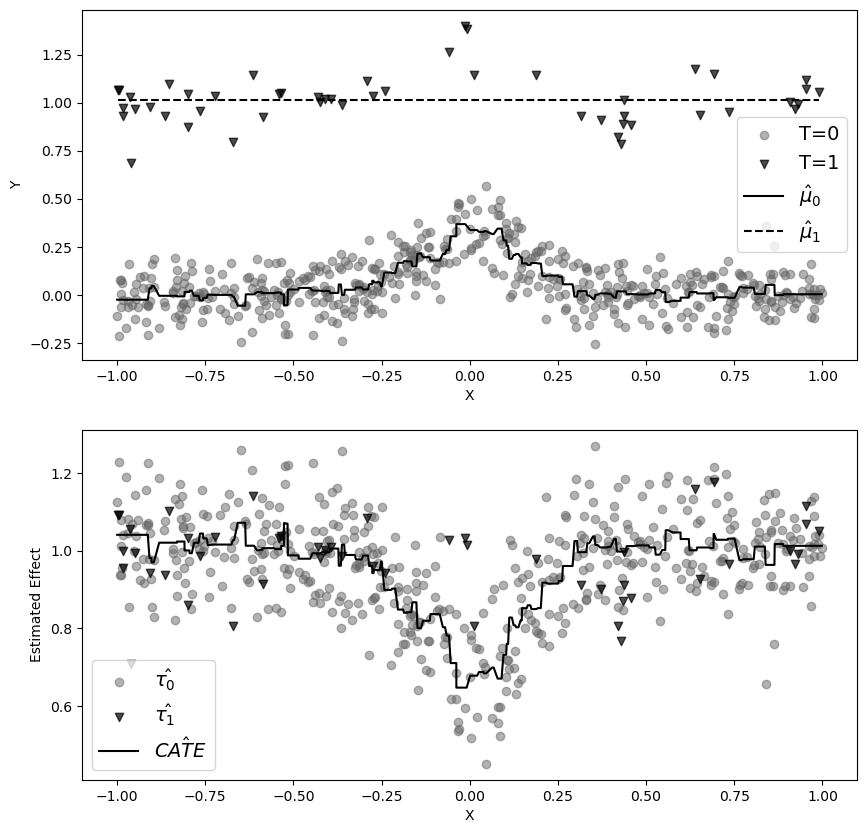

In [45]:
np.random.seed(123)

def g_kernel(x, c=0, s=0.05): 
    return np.exp((-(x-c)**2)/s)

n0 = 500
x0 = np.random.uniform(-1, 1, n0)
y0 = np.random.normal(0.3*g_kernel(x0), 0.1, n0)

n1 = 50
x1 = np.random.uniform(-1, 1, n1)
y1 = np.random.normal(0.3*g_kernel(x1), 0.1, n1)+1

df = pd.concat([pd.DataFrame(dict(x=x0, y=y0, t=0)), pd.DataFrame(dict(x=x1, y=y1, t=1))]).sort_values(by="x")

m0 = LGBMRegressor(min_child_samples=25, verbosity=-1)
m1 = LGBMRegressor(min_child_samples=25, verbosity=-1)

m0.fit(x0.reshape(-1, 1), y0)
m1.fit(x1.reshape(-1, 1), y1)

m0_hat = m0.predict(df.query("t==0")[["x"]])
m1_hat = m1.predict(df.query("t==1")[["x"]])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

ax1.scatter(x0, y0, alpha=0.5, label="T=0", marker=marker[0], color=color[1])
ax1.scatter(x1, y1, alpha=0.7, label="T=1", marker=marker[1], color=color[0])

ax1.plot(df.query("t==0")[["x"]], m0_hat, color="black", linestyle="solid",  label="$\hat{\mu}_0$")
ax1.plot(df.query("t==1")[["x"]], m1_hat, color="black", linestyle="--",  label="$\hat{\mu}_1$")

ax1.set_ylabel("Y")
ax1.set_xlabel("X")
ax1.legend(fontsize=14);

tau_0 = m1.predict(df.query("t==0")[["x"]]) - df.query("t==0")["y"]
tau_1 = df.query("t==1")["y"] - m0.predict(df.query("t==1")[["x"]])

ax2.scatter(df.query("t==0")[["x"]], tau_0, label="$\hat{\\tau_0}$", alpha=0.5, marker=marker[0], color=color[1])
ax2.scatter(df.query("t==1")[["x"]], tau_1, label="$\hat{\\tau_1}$", alpha=0.7, marker=marker[1], color=color[0])

ax2.plot(df[["x"]], m1.predict(df[["x"]]) - m0.predict(df[["x"]]), label="$\hat{CATE}$",  color="black")

ax2.set_ylabel("Estimated Effect")
ax2.set_xlabel("X")
ax2.legend(fontsize=14)
plt.show()

<br>

### 02. X 러너
- X러너는 두 가지 단계에서 머신러닝 모델과 성향점수 모델을 학습
- 예측 시, 두 번째 단계의 모델과 성향점수 모델만 활용

<img src='img/x-learner.png' width=800>

<br>

1. **표본을 실험군과 대조군으로 나누고, 각 그룹에 대한 모델을 적합**

$$
\hat{\mu}_0(X) \approx E[Y| T=0, X]
$$

$$
\hat{\mu}_1(X) \approx E[Y| T=1, X]
$$

2. **적합된 모델을 사용하여 누락된 잠재적 결과를 추정**

$$
\hat{\tau}(X, T=0) = \hat{\mu}_1(X, T=0) - Y_{T=0}
$$

$$
\hat{\tau}(X, T=1) = Y_{T=1} - \hat{\mu}_0(X, T=1)
$$

3. **추정된 효과를 예측할 두 개의 추가 모델을 적합**

$$
\hat{\mu}_{\tau 0}(X) \approx E[\hat{\tau}(X)|T=0]
$$

$$
\hat{\mu}_{\tau 1}(X) \approx E[\hat{\tau}(X)|T=1]
$$

4. **IPW 가중치 결합**
- 최종적인 CATE는 두 모델의 예측값을 가중 평균하여 계산

$$
\hat{\tau(x)} = \hat{\mu}_{\tau 0}(X)\hat{e}(x) +  \hat{\mu}_{\tau 1}(X)(1-\hat{e}(x))

$$

$$
\hat{\tau}(x) = P(T=1|X) \hat{\mu_{\tau 0}}(x) + (1-P(T=1|X))\hat{\mu_{\tau 1}}(x)
$$

<br>

#### 대조군이 많고 실험군의 데이터가 매우 적을 때
- **하나의 모델은 처치효과를 잘못 대체했기에 부정확, 하나의 모델은 그 값을 올바르게 대체했으므로 정확**

<br>


$\rightarrow$ **정확한 모델에 더 많은 가중치를 부여**

$\rightarrow$ **가중치 부여에 성향점수를 사용 가능**

$\rightarrow$ **성향점수 모델을 사용하여, 두 개의 두 번째 단계의 모델을 결합**

$$
\hat{\tau(x)} = \hat{\mu}_{\tau 0}(X)\hat{e}(x) +  \hat{\mu}_{\tau 1}(X)(1-\hat{e}(x))
$$

$\rightarrow$ **실험군이 매우 작으므로, 성향점수 $\hat{e}(x)$가 매우 작아, 잘못되 CATE모델 $\hat{\mu}(X)_{\tau_0}$에 매우 작은 가중치를 부여**

$\rightarrow$ **반대로 $1-\hat{e}(x)$는 1에 가까우므로 올바른 CATE 모델 $\hat{\mu}(X)_{\tau_1}$에 더 많은 가중치를 부여**

**일반적으로 성향점수를 사용한 이 가중평균은, 더 많은 데이터를 사용하여 학습된 $\hat{\mu_1}$ 모델에서 얻은 처치효과 추정값에 더 많은 가중치를 부여**

<br>

- **X러너는 비선형성에서 잘못 추정된 CATE를 보정하는 데 훨씬 더 나은 성능을 보이며, 일반적으로 한 실험 대상의 집단이 다른 집단보다 훨씬 클 때 X러너의 성능이 더 좋음**

<br>

#### X러너 구현 (도메인 적응 러너, Domain Adaption Learner)
- 도메인 적응 러너는 X러너의 하나로, 성향점수 모델을 사용하여 추정

<br>

- 성향점수 모델

In [48]:
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMRegressor

In [55]:
ps_model = LogisticRegression()
ps_model.fit(train[X], train[T])

LogisticRegression()

<br>

- IPW 가중치 ($1/P(T=t)$)를 모델 학습에 적용

In [54]:
train_t0 = train.query(f"{T}==0")
train_t1 = train.query(f"{T}==1")

m0 = LGBMRegressor()
m1 = LGBMRegressor()

np.random.seed(123)

m0.fit(train_t0[X], train_t0[y], sample_weight=1/ps_model.predict_proba(train_t0[X])[:, 0])
m1.fit(train_t1[X], train_t1[y], sample_weight=1/ps_model.predict_proba(train_t1[X])[:, 1]);


<br>

- **처치효과를 예측하고, 예측된 효과에 대해 두 번째 단계 모델을 적합**

In [51]:
tau_hat_0 = m1.predict(train_t0[X]) - train_t0[y]
tau_hat_1 = train_t1[y] - m0.predict(train_t1[X])

m_tau_0 = LGBMRegressor()
m_tau_1 = LGBMRegressor()

np.random.seed(123)

m_tau_0.fit(train_t0[X], tau_hat_0)
m_tau_1.fit(train_t1[X], tau_hat_1);

<br>

- **성향점수 모델을 사용하여, 두 번째 단계 모델들의 예측값을 결합하고 CATE를 계산**

In [52]:
# CATE추정
ps_test = ps_model.predict_proba(test[X])[:, 1]

x_cate_test = test.assign(
    cate=(ps_test*m_tau_0.predict(test[X]) + (1-ps_test)*m_tau_1.predict(test[X]))
)

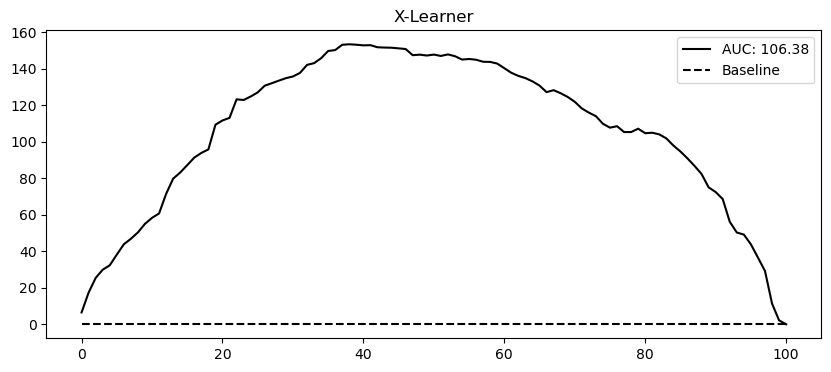

In [53]:
gain_curve_test = relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(x_cate_test, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("X-Learner")
plt.show()

<br>

<hr>

<br>

## 07-02. 연속형 처치 메타러너

In [58]:
data_cont = pd.read_csv("./data/discount_data.csv")
data_cont.head()

,rest_id,day,month,weekday,...,is_nov,competitors_price,discounts,sales
0,0,2016-01-01,1,4,...,False,2.88,0,79.0
1,0,2016-01-02,1,5,...,False,2.64,0,57.0
2,0,2016-01-03,1,6,...,False,2.08,5,294.0
3,0,2016-01-04,1,0,...,False,3.37,15,676.5
4,0,2016-01-05,1,1,...,False,3.79,0,66.0


In [59]:
train = data_cont.query("day<'2018-01-01'")
test = data_cont.query("day>='2018-01-01'")

<br>

### 01. S 러너
- **S러너는 가장 기본적인 방식으로, 단일 (Simple, S)머신러닝  모델 $\hat{\mu_s}$를 사용하여 추정**
- **장점**
    - 랜덤화된 데이터가 많고, 상대적으로 쉬운 데이터셋에 특화
    - 어떤 인과 문제에도 처음 시도하기 좋은 모델
    - 이진 및 연속형 처치 모두에 활용 가능
- **단점**
    - 처치효과를 0으로 편향시키려는 경향이 존재
    - S러너는 일반적으로 정규화 머신러닝 모델을 사용하므로, 이 정규화는 추정된 처치효과를 제한 가능

<br>

$$
\mu(x) = E[Y| T, X]
$$

<br>

- **CATE추정을 하기 위해서, 결과 $Y$를 예측하려는 모델에 처치변수를 특성으로 포함**

In [60]:
X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

np.random.seed(123)
s_learner = LGBMRegressor()
s_learner.fit(train[X+[T]], train[y]);

<br>

- 아직 모델은 처치효과를 직접 출력하지는 않고, 다양한 처치에서의 예측을 할 수 없음
- 처치가 이산형인 경우에도 이 모델은 여전히 작동할 것이고, 실험군과 대조군의 예측값 차이가 CATE 추정값

$$
\hat{\tau}(x)_i = M_s(X_i, T=1) - M_s(X_i, T=0)
$$

<img src='img/s-learner.png' width=800>

<br>

- **처치 `discounts`의 그리드를 통하여, S러너의 `discounts`의 변화에 따른 예측값 계산 $\rightarrow$ 반사실 예측**

In [61]:
t_grid = pd.DataFrame(dict(key=1,discounts=np.array([0, 10, 20, 30, 40])))

test_cf = (test
           .drop(columns=["discounts"])
           .assign(key=1)
           .merge(t_grid)
           # make predictions after expansion
           .assign(sales_hat = lambda d: s_learner.predict(d[X+[T]])))

test_cf.head(8)

,rest_id,day,month,weekday,...,sales,key,discounts,sales_hat
0,0,2018-01-01,1,0,...,251.5,1,0,67.957972
1,0,2018-01-01,1,0,...,251.5,1,10,444.245941
2,0,2018-01-01,1,0,...,251.5,1,20,793.045769
3,0,2018-01-01,1,0,...,251.5,1,30,1279.640793
4,0,2018-01-01,1,0,...,251.5,1,40,1512.630767
5,0,2018-01-02,1,1,...,541.0,1,0,65.672080
6,0,2018-01-02,1,1,...,541.0,1,10,495.669220
7,0,2018-01-02,1,1,...,541.0,1,20,1015.401471


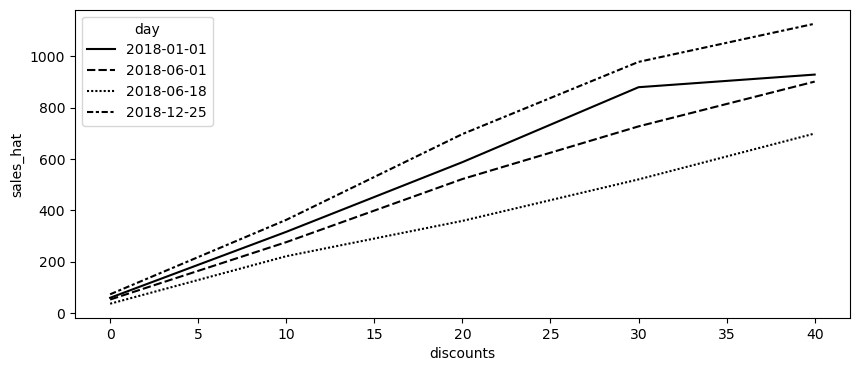

In [68]:
days = ["2018-12-25", "2018-01-01", "2018-06-01", "2018-06-18"]

plt.figure(figsize=(10, 4))
sns.lineplot(data=test_cf.query("day.isin(@days)").query("rest_id==2"),
             y="sales_hat",
             x="discounts",
             style="day");
plt.show()

<br>

#### CATE 예측
- CATE예측을 얻기 위해서 실험 대상 수준의 곡선을, **처치효과를 나타내는 단일 숫자로 요약해야함**

    $\rightarrow$ **각 실험 대상에 대해 회귀분석을 하고, 그 결과에서 처치의 기울기 매개변수를 추출하여 CATE 추정값으로 활용**

    - 기울기 매개변수만 필요하므로, 단순선형회귀 계수 공식을 사용

$$
\hat{\beta} = Cov(t, y) / Var(t)
$$

In [69]:
from toolz import curry

In [70]:
@curry
def linear_effect(df, y, t):
    return np.cov(df[y], df[t])[0, 1]/df[t].var()

<br>

- 각 관측값별 CATE 계산

In [72]:
cate = (test_cf
        .groupby(["rest_id", "day"])
        .apply(linear_effect(t="discounts", y="sales_hat"), include_groups=False)
        .rename("cate"))

test_s_learner_pred = test.set_index(["rest_id", "day"]).join(cate)

test_s_learner_pred.head()

month  weekday  weekend  is_holiday  ...  \
rest_id day                                              ...   
0       2018-01-01      1        0    False        True  ...   
        2018-01-02      1        1    False       False  ...   
        2018-01-03      1        2    False       False  ...   
        2018-01-04      1        3    False       False  ...   
        2018-01-05      1        4    False       False  ...   

                    competitors_price  discounts  sales       cate  
rest_id day                                                         
0       2018-01-01               4.92          5  251.5  37.247404  
        2018-01-02               3.06         10  541.0  40.269854  
        2018-01-03               4.61         10  431.0  37.412988  
        2018-01-04               4.84         20  760.0  38.436815  
        2018-01-05               6.29          0   78.0  31.428603  

[5 rows x 10 columns]

<br>

- 누적 이득 곡선

In [73]:
from fklearn.causal.validation.auc import area_under_the_relative_cumulative_gain_curve
from fklearn.causal.validation.curves import relative_cumulative_gain_curve

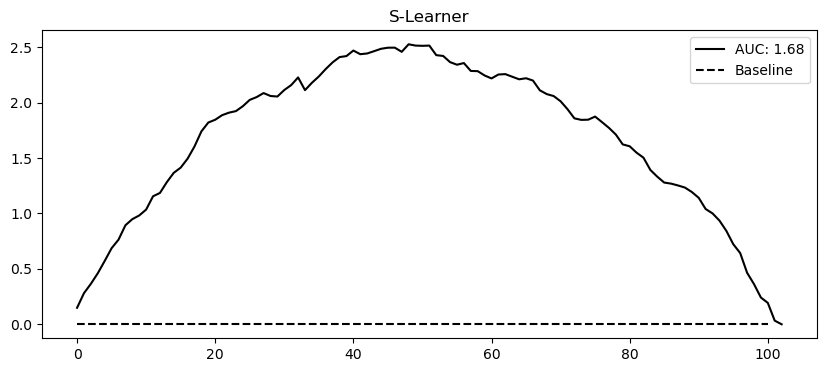

In [75]:
gain_curve_test = relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_s_learner_pred, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("S-Learner")
plt.show()

<br>

#### S러너의 단점
- **처치효과를 0으로 편향시키려는 경향 $\rightarrow$ S러너는 일반적으로 정규화 머신러닝 모델을 사용하기에, 이 정규화는 추정된 처치효과를 제한**
- 빅터 체르노주코프 (Victor Chernozhukov)의 연구
    - 20개의 공변량과 실제 ATE가 1인 이진 처치로 데이터를 시뮬레이션
    - S러너를 사용하여 ATE를 추정
    - 이 시뮬레이션과 추정 단계를 500회 반복하고 추정된 ATE의 분포를 실제 ATE와 비교

    $\rightarrow$ **추정된 ATE의 분포가 실제 ATE보다 편향되어 0으로 향함**

- **처치변수가 다른 공변량보다 결과를 설명하는 데 영향력이 매우 작다면, S러너는 처치변수를 완전히 버릴 수 있으며, 머신러닝 모델의 정규화가 클 수록 이 문제는 증폭됨**

    $\rightarrow$ **이중/편향 제거 머신러닝 또는 R러너**

<br>

<img src='img/zero-bias-s-learner.png' width=400>




<br>

### 02. 이중/편향 제거 머신러닝


In [23]:
from sklearn.model_selection import cross_val_predict

X = ["month", "weekday", "is_holiday", "competitors_price"]
T = "discounts"
y = "sales"

debias_m = LGBMRegressor()
denoise_m = LGBMRegressor()

t_res =  train[T] - cross_val_predict(debias_m,train[X],train[T],cv=5)
y_res =  train[y] - cross_val_predict(denoise_m,train[X],train[y],cv=5)

In [24]:
import statsmodels.api as sm

sm.OLS(y_res, t_res).fit().summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
discounts,31.4615,0.151,208.990,0.000,31.166,31.757


<br>

### 01. 이중 머신러닝으로 CATE 추정


In [25]:
y_star = y_res/t_res
w = t_res**2

cate_model = LGBMRegressor().fit(train[X], y_star, sample_weight=w)

test_r_learner_pred = test.assign(cate = cate_model.predict(test[X]))

Text(0.5, 1.0, 'R-Learner')

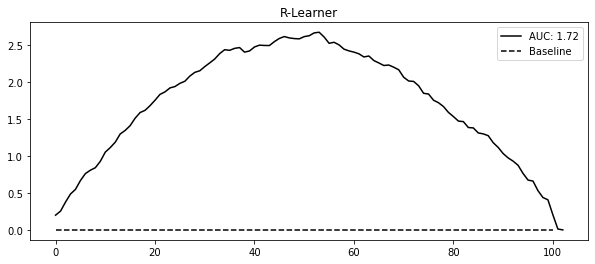

In [26]:
gain_curve_test = relative_cumulative_gain_curve(test_r_learner_pred, T, y, prediction="cate")
auc = area_under_the_relative_cumulative_gain_curve(test_r_learner_pred, T, y, prediction="cate")

plt.figure(figsize=(10, 4))
plt.plot(gain_curve_test, color="C0", label=f"AUC: {auc:.2f}")
plt.hlines(0, 0, 100, linestyle="--", color="black", label="Baseline")

plt.legend();
plt.title("R-Learner")

<br>

### 02. 이중 머신러닝에 대한 시각적인 직관


In [27]:
np.random.seed(123)
n = 5000

x_h = np.random.randint(1, 4, n)
x_c = np.random.uniform(-1, 1, n)

t = np.random.normal(10 + 1*x_c + 3*x_c**2 + x_c**3, 0.3)
y = np.random.normal(t + x_h*t - 5*x_c - x_c**2 - x_c**3, 0.3)

df_sim = pd.DataFrame(dict(x_h=x_h, x_c=x_c, t=t, y=y))

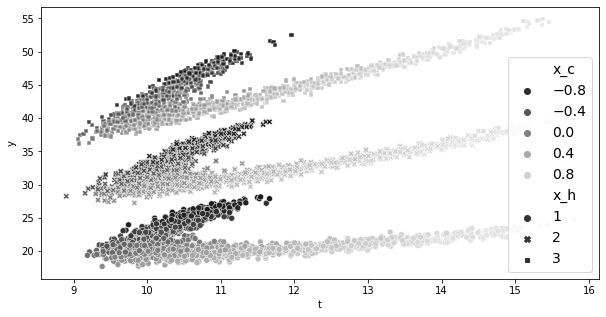

In [28]:
import matplotlib

plt.figure(figsize=(10, 5))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["0.1","0.5","0.9"])

sns.scatterplot(data=df_sim, y="y", x="t", hue="x_c", style="x_h", palette=cmap);
plt.legend(fontsize=14)

In [29]:
debias_m = LGBMRegressor(max_depth=3)
denoise_m = LGBMRegressor(max_depth=3)

t_res = cross_val_predict(debias_m, df_sim[["x_c"]], df_sim["t"],
                          cv=10)

y_res = cross_val_predict(denoise_m, df_sim[["x_c", "x_h"]],df_sim["y"],
                          cv=10)

df_res = df_sim.assign(
    t_res =  df_sim["t"] - t_res,
    y_res =  df_sim["y"] - y_res
)

In [30]:
import statsmodels.formula.api as smf

smf.ols("y_res~t_res", data=df_res).fit().params["t_res"]

3.045230146006292

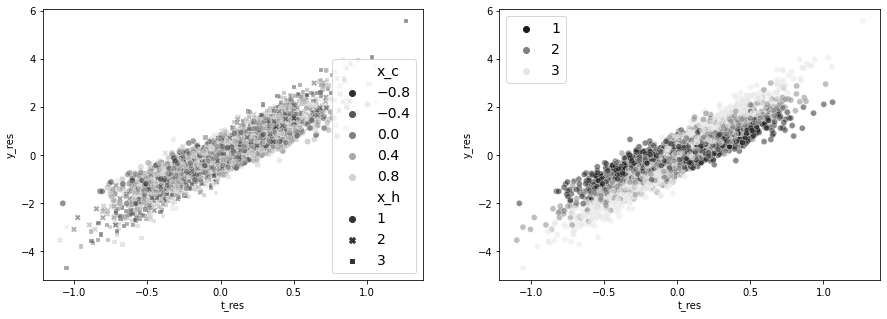

In [31]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1 = sns.scatterplot(data=df_res, y="y_res", x="t_res", hue="x_c", style="x_h", alpha=0.5, ax=ax1, palette=cmap)

h,l = ax1.get_legend_handles_labels()
ax1.legend(fontsize=14)

sns.scatterplot(data=df_res, y="y_res", x="t_res", hue="x_h", ax=ax2, alpha=0.5, palette=cmap)
ax2.legend(fontsize=14)


In [32]:
df_star = df_res.assign(
    y_star = df_res["y_res"]/df_res["t_res"],
    weight = df_res["t_res"]**2,
)

for x in range(1, 4):
    cate = np.average(df_star.query(f"x_h=={x}")["y_star"],
                      weights=df_star.query(f"x_h=={x}")["weight"])
    
    print(f"CATE x_h={x}", cate)

CATE x_h=1 2.019759619990067
CATE x_h=2 2.974967932350952
CATE x_h=3 3.9962382855476957


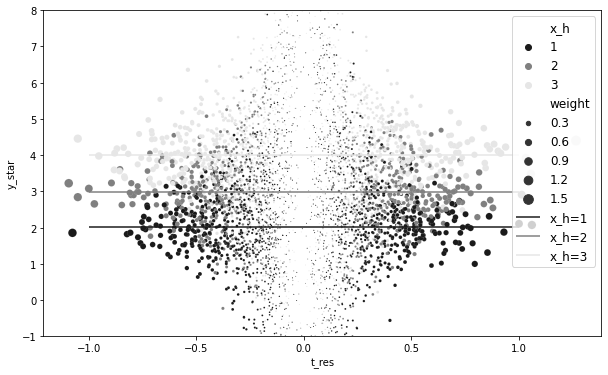

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_star, palette=cmap,
                y="y_star", x="t_res", hue="x_h", size="weight", sizes=(1, 100)), 

plt.hlines(np.average(df_star.query("x_h==1")["y_star"], weights=df_star.query("x_h==1")["weight"]),
           -1, 1, label="x_h=1", color="0.1")

plt.hlines(np.average(df_star.query("x_h==2")["y_star"], weights=df_star.query("x_h==2")["weight"]),
           -1, 1, label="x_h=2", color="0.5")

plt.hlines(np.average(df_star.query("x_h==3")["y_star"], weights=df_star.query("x_h==3")["weight"]),
           -1, 1, label="x_h=3", color="0.9")

plt.ylim(-1, 8)

plt.legend(fontsize=12)



## 7.3 요약